In [118]:
from pathlib import Path
import sys

src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from main import *
from scipy.linalg import expm
from scipy.optimize import nnls

In [119]:
def dissipator_from_builder(builder, jump_operator):
    """
    Construct the Liouville-space matrix D[L] using the user's
    existing LiouvillianBuilder and Jump classes.
    """
    zero_H = np.zeros(
        (builder.d, builder.d),
        dtype=np.complex128,
    )

    return builder.build(
        zero_H,
        [Jump(jump_operator, 1.0)],
    )

def annihilation_operator(dim: int) -> np.ndarray:
    """
    Harmonic-oscillator lowering operator in a truncated Fock basis

        |0>, |1>, ..., |dim-1>.

    Matrix elements:
        <m|a|n> = sqrt(n) delta_{m,n-1}.
    """
    if dim < 1:
        raise ValueError("dim must be at least 1.")

    return np.diag(
        np.sqrt(np.arange(1, dim, dtype=float)),
        k=1,
    ).astype(np.complex128)


def creation_operator(dim: int) -> np.ndarray:
    """Truncated harmonic-oscillator raising operator a†."""
    return annihilation_operator(dim).conj().T

def thermal_harmonic_oscillator_model(
    dim: int,
    omega: float,
    beta: float,
    gamma: float,
):
    """
    Construct a time-independent thermal harmonic-oscillator model.

    Master equation:

        drho/dt = -i[H, rho]
                  + gamma*(nbar + 1)*D[a](rho)
                  + gamma*nbar*D[a†](rho).
    """
    if dim < 2:
        raise ValueError("dim must be at least 2.")
    if omega <= 0.0:
        raise ValueError("omega must be positive.")
    if beta <= 0.0:
        raise ValueError("beta must be positive.")
    if gamma < 0.0:
        raise ValueError("gamma must be non-negative.")

    a = annihilation_operator(dim)
    adag = a.conj().T
    number = adag @ a

    # The omitted omega/2 identity only contributes a global phase
    # and therefore drops out of [H, rho].
    H = omega * number

    nbar = 1.0 / np.expm1(beta * omega)

    def H_of_t(t):
        return H

    def jumps_of_t(t):
        return [
            Jump(a, gamma * (nbar + 1.0)),
            Jump(adag, gamma * nbar),
        ]

    model = LindbladModel2LS(H_of_t, jumps_of_t)
    return model, a, adag, nbar

In [120]:
def dissipator_actions(
    rho_ss: np.ndarray,
    jump_operators,
) -> np.ndarray:
    """
    Return

        O_j = D[L_j](rho_ss)

    for every jump operator L_j.

    Returns
    -------
    O : ndarray, shape (n_jumps, d, d)
        O[j] = D[L_j](rho_ss).
    """
    rho_ss = np.asarray(rho_ss, dtype=np.complex128)

    if rho_ss.ndim != 2 or rho_ss.shape[0] != rho_ss.shape[1]:
        raise ValueError("rho_ss must be a square matrix.")

    d = rho_ss.shape[0]
    jump_operators = tuple(jump_operators)

    O = np.empty(
        (len(jump_operators), d, d),
        dtype=np.complex128,
    )

    for j, L in enumerate(jump_operators):
        L = np.asarray(L, dtype=np.complex128)

        if L.shape != (d, d):
            raise ValueError(
                f"jump_operators[{j}] has shape {L.shape}; "
                f"expected {(d, d)}."
            )

        Ldag = L.conj().T
        LdagL = Ldag @ L

        O[j] = (
            L @ rho_ss @ Ldag
            - 0.5 * (LdagL @ rho_ss + rho_ss @ LdagL)
        )

    return O

import numpy as np


def var_AGP_Urot(
    rho_ss: np.ndarray,
    partial_s_rho_ss: np.ndarray,
    hamiltonians,
    lam: float = 0.0,
    *,
    rcond: float = 1e-12,
    return_details: bool = False,
):
    """
    Fit a signed Hamiltonian counterdiabatic term

        H_CD = sum_j x_j H_j

    by minimising

        || partial_s_rho_ss + i sum_j x_j [H_j, rho_ss] ||_F^2
        + lam * ||x||_2^2,

    where x_j are real and may have either sign.

    For lam = 0, this returns the Moore-Penrose minimum-norm
    least-squares solution.

    Parameters
    ----------
    rho_ss : ndarray, shape (d, d)
        Instantaneous steady-state density matrix.

    partial_s_rho_ss : ndarray, shape (d, d)
        Derivative partial_s rho_ss.

    hamiltonians : sequence of ndarray
        Candidate Hermitian operators H_j.

    lam : float, optional
        Non-negative Tikhonov regularisation strength.
        lam = 0 gives the Moore-Penrose solution.

    rcond : float, optional
        Singular-value cutoff used by np.linalg.pinv when lam = 0.

    return_details : bool, optional
        If True, also return diagnostic quantities.

    Returns
    -------
    x : ndarray, shape (n_hamiltonians,)
        Optimal real, signed Hamiltonian coefficients.

    residual : ndarray, shape (d, d)
        Residual at the optimum:

            partial_s_rho_ss + i sum_j x_j [H_j, rho_ss].

    details : dict, optional
        Returned only if return_details=True.
    """
    rho_ss = np.asarray(rho_ss, dtype=np.complex128)
    partial_s_rho_ss = np.asarray(
        partial_s_rho_ss,
        dtype=np.complex128,
    )
    hamiltonians = tuple(
        np.asarray(H, dtype=np.complex128)
        for H in hamiltonians
    )

    if rho_ss.ndim != 2 or rho_ss.shape[0] != rho_ss.shape[1]:
        raise ValueError("rho_ss must be a square matrix.")

    if partial_s_rho_ss.shape != rho_ss.shape:
        raise ValueError(
            "partial_s_rho_ss must have the same shape as rho_ss."
        )

    if len(hamiltonians) == 0:
        raise ValueError("At least one Hamiltonian is required.")

    if lam < 0:
        raise ValueError("lam must be non-negative.")

    if any(H.shape != rho_ss.shape for H in hamiltonians):
        raise ValueError(
            "Every Hamiltonian must have the same shape as rho_ss."
        )

    # C_j = i [H_j, rho_ss].
    #
    # The residual is:
    #
    #     R = partial_s_rho_ss + sum_j x_j C_j.
    commutator_actions = np.array([
        1j * (H @ rho_ss - rho_ss @ H)
        for H in hamiltonians
    ])

    A_complex = np.column_stack([
        C_j.reshape(-1, order="F")
        for C_j in commutator_actions
    ])
    d_complex = partial_s_rho_ss.reshape(-1, order="F")

    # x must be real, so represent the complex Frobenius norm as a
    # real Euclidean norm.
    A_real = np.vstack([A_complex.real, A_complex.imag])
    d_real = np.concatenate([d_complex.real, d_complex.imag])

    # Minimise ||A_real @ x + d_real||^2 + lam ||x||^2.
    if lam == 0.0:
        # Moore-Penrose, minimum-norm least-squares solution.
        x = -np.linalg.pinv(A_real, rcond=rcond) @ d_real
    else:
        # Tikhonov-regularised signed least squares.
        normal_matrix = A_real.T @ A_real + lam * np.eye(len(hamiltonians))
        rhs = -A_real.T @ d_real
        x = np.linalg.solve(normal_matrix, rhs)

    residual = partial_s_rho_ss + np.tensordot(
        x,
        commutator_actions,
        axes=(0, 0),
    )

    if not return_details:
        return x, residual

    residual_norm_squared = float(np.vdot(residual, residual).real)
    x_norm_squared = float(x @ x)

    details = {
        "residual_norm_squared": residual_norm_squared,
        "x_norm_squared": x_norm_squared,
        "objective": residual_norm_squared + lam * x_norm_squared,
        "commutator_actions": commutator_actions,
        "fitted_hamiltonian": sum(
            coefficient * H
            for coefficient, H in zip(x, hamiltonians)
        ),
    }

    return x, residual, details


def var_AGP_Dpop(
    rho_ss: np.ndarray,
    target: np.ndarray,
    jump_operators,
    lam: float = 0.0,
    *,
    return_details: bool = False,
    verbose: bool = False,
):
    """
    Solve the regularised non-negative least-squares problem

        min_{gamma_j >= 0}
            ||sum_j gamma_j D[L_j](rho_ss)
              - target||_F^2
            + lam * ||gamma||_2^2.

    Parameters
    ----------
    rho_ss : ndarray, shape (d, d)
        Instantaneous steady state.

    target : ndarray, shape (d, d)
        This is generally the residual after we minimise the norm of the unitary part, need to mop up what's left with the dissipator.

    jump_operators : sequence of ndarray
        Candidate jump operators L_j.

    lam : float, optional
        Non-negative L2 regularisation parameter.

    return_details : bool, optional
        If False, return only gamma.
        If True, also return diagnostic quantities and Jump objects.

    verbose : bool, optional
        Print the fitted norms. Off by default.

    Returns
    -------
    gamma : ndarray, shape (n_jumps,)
        Optimal non-negative rates.

    details : dict, optional
        Returned only when return_details=True.
    """
    rho_ss = np.asarray(rho_ss, dtype=np.complex128)
    target = np.asarray(
        target,
        dtype=np.complex128,
    )
    jump_operators = tuple(jump_operators)

    if rho_ss.ndim != 2 or rho_ss.shape[0] != rho_ss.shape[1]:
        raise ValueError("rho_ss must be a square matrix.")

    if target.shape != rho_ss.shape:
        raise ValueError(
            "target must have the same shape as rho_ss."
        )

    if lam < 0.0:
        raise ValueError("lam must be non-negative.")

    if len(jump_operators) == 0:
        raise ValueError("At least one jump operator is required.")

    # O_j = D[L_j](rho_ss)
    O = dissipator_actions(rho_ss, jump_operators)

    # Construct the complex design matrix:
    #
    #     A[:, j] = vec(O_j)
    #
    # using the same column-major convention as LiouvillianBuilder.
    A_complex = np.column_stack([
        O_j.reshape(-1, order="F")
        for O_j in O
    ])

    b_complex = target.reshape(-1, order="F")

    # gamma is real, so convert the complex least-squares problem into
    # an equivalent real one.
    A_real = np.vstack([
        A_complex.real,
        A_complex.imag,
    ])
    b_real = np.concatenate([
        b_complex.real,
        b_complex.imag,
    ])

    n_jumps = len(jump_operators)

    # Tikhonov regularisation:
    #
    # ||A gamma - b||^2 + lam ||gamma||^2
    #
    # becomes the augmented NNLS problem
    #
    # || [A; sqrt(lam) I] gamma - [b; 0] ||^2.
    if lam > 0.0:
        A_fit = np.vstack([
            A_real,
            np.sqrt(lam) * np.eye(n_jumps),
        ])
        b_fit = np.concatenate([
            b_real,
            np.zeros(n_jumps),
        ])
    else:
        A_fit = A_real
        b_fit = b_real

    gamma, _ = nnls(A_fit, b_fit)

    if not return_details and not verbose:
        return gamma

    fitted_derivative = np.tensordot(
        gamma,
        O,
        axes=(0, 0),
    )

    residual = fitted_derivative - target

    residual_norm_squared = float(
        np.vdot(residual, residual).real
    )
    gamma_norm_squared = float(gamma @ gamma)
    objective = (
        residual_norm_squared
        + lam * gamma_norm_squared
    )

    if verbose:
        print("Residual norm squared:", residual_norm_squared)
        print("Gamma norm squared:", gamma_norm_squared)
        print("Regularised objective:", objective)

    if not return_details:
        return gamma

    details = {
        "residual_norm_squared": residual_norm_squared,
        "gamma_norm_squared": gamma_norm_squared,
        "objective": objective,
        "fitted_derivative": fitted_derivative,
        "dissipator_actions": O,

        # Directly compatible with builder.build(H, jumps).
        "weighted_jumps": [
            Jump(L, rate)
            for L, rate in zip(jump_operators, gamma)
        ],

        # Keeps the correspondence between rate, operator, and action.
        "terms": [
            {
                "gamma": gamma[j],
                "L": jump_operators[j],
                "O": O[j],
            }
            for j in range(n_jumps)
        ],
    }

    return gamma, details


def fit_overall_AGP(
    rho_ss: np.ndarray,
    partial_s_rho_ss: np.ndarray,
    hamiltonians,
    jump_operators,
    *,
    lam_unitary: float = 0.0,
    lam_dissipative: float = 0.0,
    rcond: float = 1e-12,
    return_details: bool = False,
):
    """
    Sequentially fit a Hamiltonian and dissipative AGP.

    Step 1: fit the signed unitary contribution

        partial_s rho_ss + i sum_j x_j [H_j, rho_ss] ~ 0.

    Step 2: let positive dissipative rates reproduce the remaining
    unitary residual:

        sum_k gamma_k D[L_k](rho_ss) ~ residual_unitary,

    where

        residual_unitary
        = partial_s rho_ss + i sum_j x_j [H_j, rho_ss].

    Thus the final residual, in this convention, is

        residual_total
        = residual_unitary - sum_k gamma_k D[L_k](rho_ss).

    Parameters
    ----------
    rho_ss, partial_s_rho_ss : ndarray
        Instantaneous steady state and its derivative.

    hamiltonians : sequence of ndarray
        Candidate Hermitian terms H_j.

    jump_operators : sequence of ndarray
        Candidate jump operators L_k.

    lam_unitary, lam_dissipative : float
        L2 regularisation strengths for x and gamma respectively.

    rcond : float
        Pseudoinverse cutoff for the unitary fit.

    return_details : bool
        If False, return (x, gamma, residual_total).
        If True, additionally return a diagnostics dictionary.

    Returns
    -------
    x : ndarray
        Signed coefficients of the Hamiltonian terms.

    gamma : ndarray
        Non-negative coefficients of the dissipative terms.

    residual_total : ndarray
        Remaining residual after both fits.
    """
    # ---------------------------------------------------------------
    # 1. Unitary contribution:
    #
    # R_U = partial_s rho_ss + i sum_j x_j [H_j, rho_ss].
    # ---------------------------------------------------------------
    x, residual_unitary, unitary_details = var_AGP_Urot(
        rho_ss=rho_ss,
        partial_s_rho_ss=partial_s_rho_ss,
        hamiltonians=hamiltonians,
        lam=lam_unitary,
        rcond=rcond,
        return_details=True,
    )

    # ---------------------------------------------------------------
    # 2. Dissipative contribution:
    #
    # Find D_fit = sum_k gamma_k D[L_k](rho_ss) ~= R_U.
    # ---------------------------------------------------------------
    gamma, dissipative_details = var_AGP_Dpop(
        rho_ss=rho_ss,
        target=residual_unitary,
        jump_operators=jump_operators,
        lam=lam_dissipative,
        return_details=True,
    )

    fitted_dissipative_derivative = (
        dissipative_details["fitted_derivative"]
    )

    # var_AGP_Dpop defines its own residual as D_fit - R_U.
    # Here we use the physically clearer opposite convention:
    #
    # R_total = R_U - D_fit.
    residual_total = (
        residual_unitary - fitted_dissipative_derivative
    )

    if not return_details:
        return x, gamma, residual_total

    total_residual_norm_squared = float(
        np.vdot(residual_total, residual_total).real
    )

    details = {
        "x": x,
        "gamma": gamma,

        "residual_unitary": residual_unitary,
        "residual_unitary_norm_squared": float(
            np.vdot(residual_unitary, residual_unitary).real
        ),

        "fitted_dissipative_derivative":
            fitted_dissipative_derivative,

        "residual_total": residual_total,
        "residual_total_norm_squared":
            total_residual_norm_squared,

        "unitary": unitary_details,
        "dissipative": dissipative_details,

        "H_agp": unitary_details["fitted_hamiltonian"],
        "weighted_jumps": dissipative_details["weighted_jumps"],
    }

    return x, gamma, residual_total, details

In [121]:
dim = 20
omega = 1.0
beta = 2.0
gamma = 0.1

model, a, adag, nbar = thermal_harmonic_oscillator_model(
    dim=dim,
    omega=omega,
    beta=beta,
    gamma=gamma,
)

builder = LiouvillianBuilder(dim=dim)

H = model.H(0.0)
jumps = model.jumps(0.0)

L_total = builder.build(H, jumps)

print("Thermal occupation:", nbar)
print("Hamiltonian shape:", H.shape)
print("Liouvillian shape:", L_total.shape)

20
Thermal occupation: 0.15651764274966565
Hamiltonian shape: (20, 20)
Liouvillian shape: (400, 400)


## 1. Example of tuning the temperature for CD
First we want to consider varying $\beta$. The best way to do this is to use the analytic solution. Then, once we find that, we want to consider
$$\partial_s \rho_{ss} = \mathcal{A}_s \rho_{ss}.$$

### Working out the case for the Harmonic Oscillator with a finite temp bath

In [109]:
#---------------------
# Caclulate the target
#----------------------

N = adag @ a

rho_unnormalized = expm(-beta * omega * N)
rho_ss = rho_unnormalized / np.trace(rho_unnormalized)

mean_N = np.trace(N @ rho_ss).real

#Target for what action of superoperator should give.
drho_ss_dbeta = -omega * (
    N - mean_N * np.eye(N.shape[0])
) @ rho_ss

#---------------------
# Variational Calculation
#---------------------
jump_operators = [a@a,adag@a]

gamma, results = fit_dissipative_agp_nnls(
    rho_ss,
    drho_ss_dbeta,
    jump_operators,
    lam=0.0,
    return_details=True,
)

print(gamma)
print("Residual norm squared:", results["residual_norm_squared"])
print("Gamma norm squared:", results["gamma_norm_squared"])
print("Theory value of gamma if we just have 'a':", omega/(1-np.exp(-beta*omega)))

[1.84726402 0.        ]
Residual norm squared: 0.02171166799865196
Gamma norm squared: 3.4123843770715054
Theory value of gamma if we just have 'a': 1.1565176427496657


In [116]:
# ============================================================
# Small helpers
# ============================================================

def thermal_rho_ss_and_derivative(dim, omega, beta):
    """
    Return rho_ss(beta) and d rho_ss / d beta for the truncated
    harmonic oscillator with H = omega * N.
    """
    a = annihilation_operator(dim)
    adag = creation_operator(dim)
    Nop = adag @ a

    rho_unnormalized = expm(-beta * omega * Nop)
    rho_ss = rho_unnormalized / np.trace(rho_unnormalized)

    mean_N = np.trace(Nop @ rho_ss).real
    drho_dbeta = -omega * (Nop - mean_N * np.eye(dim)) @ rho_ss

    # enforce Hermiticity numerically
    rho_ss = 0.5 * (rho_ss + rho_ss.conj().T)
    drho_dbeta = 0.5 * (drho_dbeta + drho_dbeta.conj().T)

    return rho_ss, drho_dbeta


def nearest_index(grid, x):
    idx = np.searchsorted(grid, x)
    if idx <= 0:
        return 0
    if idx >= len(grid):
        return len(grid) - 1
    if abs(x - grid[idx - 1]) <= abs(grid[idx] - x):
        return idx - 1
    return idx


def purity_of_rho(rho):
    return np.real(np.trace(rho @ rho))


def mean_number_of_rho(rho, Nop):
    return np.real(np.trace(Nop @ rho))


def trace_distance(rho, sigma):
    """
    Trace distance T(rho,sigma) = 1/2 ||rho-sigma||_1.
    Since rho-sigma is Hermitian, use eigvalsh.
    """
    delta = 0.5 * ((rho - sigma) + (rho - sigma).conj().T)
    eigs = np.linalg.eigvalsh(delta)
    return 0.5 * np.sum(np.abs(eigs))


def linear_beta_schedule(beta_i, beta_f, T):
    slope = (beta_f - beta_i) / T

    def beta_of_t(t):
        t_clip = min(max(float(t), 0.0), T)
        return beta_i + slope * t_clip

    def betadot_of_t(t):
        # valid because we only simulate on [0,T]
        return slope

    return beta_of_t, betadot_of_t


# ============================================================
# Precompute the variational CD coefficients on a time grid
# ============================================================

def precompute_variational_cd_data(
    dim,
    omega,
    t_eval,
    beta_of_t,
    jump_operators,
    lam=0.0,
):
    """
    For each time in t_eval:
      - build rho_ss(beta(t))
      - build d rho_ss / d beta
      - fit A_beta(rho_ss) ~ d rho_ss / d beta
    """
    rho_ss_list = []
    drho_dbeta_list = []
    gamma_cd_list = []
    residuals = []
    gamma_norms = []

    for t in t_eval:
        beta_t = beta_of_t(t)
        rho_ss, drho_dbeta = thermal_rho_ss_and_derivative(
            dim, omega, beta_t
        )

        gamma_cd, details = fit_dissipative_agp_nnls(
            rho_ss,
            drho_dbeta,
            jump_operators,
            lam=lam,
            return_details=True,
            verbose=False,
        )

        rho_ss_list.append(rho_ss)
        drho_dbeta_list.append(drho_dbeta)
        gamma_cd_list.append(gamma_cd)
        residuals.append(details["residual_norm_squared"])
        gamma_norms.append(details["gamma_norm_squared"])

    return {
        "rho_ss": np.array(rho_ss_list),
        "drho_dbeta": np.array(drho_dbeta_list),
        "gamma_cd": np.array(gamma_cd_list),
        "residuals": np.array(residuals),
        "gamma_norms": np.array(gamma_norms),
    }


# ============================================================
# Build bare and CD-corrected time-dependent models
# ============================================================

def build_bare_and_cd_models(
    dim,
    omega,
    bath_gamma,
    beta_of_t,
    betadot_of_t,
    t_eval,
    jump_operators,
    gamma_cd_grid,
):
    a = annihilation_operator(dim)
    adag = creation_operator(dim)
    Nop = adag @ a
    H = omega * Nop

    def H_of_t(t):
        return H

    def bare_jumps_of_t(t):
        beta_t = beta_of_t(t)
        nbar = 1.0 / np.expm1(beta_t * omega)

        return [
            Jump(a, bath_gamma * (nbar + 1.0)),
            Jump(adag, bath_gamma * nbar),
        ]

    def cd_jumps_of_t(t):
        jumps = bare_jumps_of_t(t)

        idx = nearest_index(t_eval, float(t))
        prefactor = betadot_of_t(t)
        gamma_cd = gamma_cd_grid[idx]

        # CD contribution: dot(beta) * sum_j gamma_j(beta) D[L_j]
        for L, g in zip(jump_operators, gamma_cd):
            rate = prefactor * g
            if abs(rate) > 0.0:
                jumps.append(Jump(L, rate))

        return jumps

    bare_model = LindbladModel2LS(H_of_t, bare_jumps_of_t)
    cd_model = LindbladModel2LS(H_of_t, cd_jumps_of_t)

    return bare_model, cd_model


# ============================================================
# Main plotting function
# ============================================================

def plot_variational_cd_performance(
    dim=12,
    omega=1.0,
    bath_gamma=1.0,
    beta_i=0.3,
    beta_f=1.5,
    T=2.0,
    n_times=250,
    lam=0.0,
    *,
    jump_operators=None,
    verbose=True,
):
    """
    Compare bare evolution against variational-CD-corrected evolution.

    Notes
    -----
    - Choose beta_f > beta_i so that dot(beta) > 0, otherwise the
      CD rates dot(beta)*gamma_j become negative and the correction
      is no longer GKSL.
    - If jump_operators is None, uses [a@a, adag@a].
    """

    if beta_f <= beta_i:
        raise ValueError(
            "For this GKSL CD construction, choose beta_f > beta_i "
            "so that dot(beta) > 0."
        )

    a = annihilation_operator(dim)
    adag = creation_operator(dim)
    Nop = adag @ a

    if jump_operators is None:
        # IMPORTANT: use a @ a, not a**2
        jump_operators = [a @ a, adag @ a]

    t_eval = np.linspace(0.0, T, n_times)
    beta_of_t, betadot_of_t = linear_beta_schedule(beta_i, beta_f, T)

    # Precompute the fitted CD coefficients gamma_j(beta(t))
    cd_data = precompute_variational_cd_data(
        dim=dim,
        omega=omega,
        t_eval=t_eval,
        beta_of_t=beta_of_t,
        jump_operators=jump_operators,
        lam=lam,
    )

    if verbose:
        print("Mean fit residual:", np.mean(cd_data["residuals"]))
        print("Max fit residual :", np.max(cd_data["residuals"]))
        print("Mean ||gamma||^2 :", np.mean(cd_data["gamma_norms"]))
        print("First fitted gamma vector:", cd_data["gamma_cd"][0])
        print("Last fitted gamma vector :", cd_data["gamma_cd"][-1])

    # Build bare and CD models
    bare_model, cd_model = build_bare_and_cd_models(
        dim=dim,
        omega=omega,
        bath_gamma=bath_gamma,
        beta_of_t=beta_of_t,
        betadot_of_t=betadot_of_t,
        t_eval=t_eval,
        jump_operators=jump_operators,
        gamma_cd_grid=cd_data["gamma_cd"],
    )

    builder = LiouvillianBuilder(dim=dim)
    evolver_bare = LindbladEvolver(bare_model, builder)
    evolver_cd = LindbladEvolver(cd_model, builder)

    # Initial state: exact initial instantaneous steady state
    rho0 = cd_data["rho_ss"][0]

    traj_bare = evolver_bare.simulate(rho0, t_eval)
    traj_cd = evolver_cd.simulate(rho0, t_eval)

    # Extract observables and distances
    rho_ss_t = cd_data["rho_ss"]

    n_ss = np.zeros(n_times)
    pur_ss = np.zeros(n_times)

    n_bare = np.zeros(n_times)
    pur_bare = np.zeros(n_times)
    dist_bare = np.zeros(n_times)

    n_cd = np.zeros(n_times)
    pur_cd = np.zeros(n_times)
    dist_cd = np.zeros(n_times)

    for k in range(n_times):
        rho_target = rho_ss_t[k]
        rho_bare = traj_bare.rho(k)
        rho_cd_k = traj_cd.rho(k)

        # small Hermitisation to suppress numerical noise
        rho_bare = 0.5 * (rho_bare + rho_bare.conj().T)
        rho_cd_k = 0.5 * (rho_cd_k + rho_cd_k.conj().T)

        n_ss[k] = mean_number_of_rho(rho_target, Nop)
        pur_ss[k] = purity_of_rho(rho_target)

        n_bare[k] = mean_number_of_rho(rho_bare, Nop)
        pur_bare[k] = purity_of_rho(rho_bare)
        dist_bare[k] = trace_distance(rho_bare, rho_target)

        n_cd[k] = mean_number_of_rho(rho_cd_k, Nop)
        pur_cd[k] = purity_of_rho(rho_cd_k)
        dist_cd[k] = trace_distance(rho_cd_k, rho_target)

    # ========================================================
    # Plot
    # ========================================================
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 4.4), constrained_layout=True)

    # Left panel: path in observable space
    ax[0].plot(
        n_ss, pur_ss,
        "--",
        linewidth=2.2,
        label="instantaneous steady state",
    )
    ax[0].plot(
        n_bare, pur_bare,
        linewidth=2.2,
        label="bare evolution",
    )
    ax[0].plot(
        n_cd, pur_cd,
        linewidth=2.2,
        label="with variational CD",
    )

    ax[0].scatter([n_ss[0]], [pur_ss[0]], s=35, zorder=5, label="start")
    ax[0].scatter([n_ss[-1]], [pur_ss[-1]], s=35, zorder=5, label="end")

    ax[0].set_xlabel(r"$\langle N \rangle$")
    ax[0].set_ylabel(r"${\rm Tr}(\rho^2)$")
    ax[0].set_title("Path in state space")
    ax[0].legend(frameon=False)

    # Right panel: distance from instantaneous steady state
    ax[1].plot(
        t_eval, dist_bare,
        linewidth=2.2,
        label="bare evolution",
    )
    ax[1].plot(
        t_eval, dist_cd,
        linewidth=2.2,
        label="with variational CD",
    )

    ax[1].set_xlabel(r"$t$")
    ax[1].set_ylabel(r"$\frac{1}{2}\|\rho(t)-\rho_{\rm ss}(t)\|_1$")
    ax[1].set_title("Deviation from instantaneous steady state")
    ax[1].legend(frameon=False)

    plt.show()

    return {
        "t_eval": t_eval,
        "rho_ss_t": rho_ss_t,
        "traj_bare": traj_bare,
        "traj_cd": traj_cd,
        "gamma_cd_grid": cd_data["gamma_cd"],
        "fit_residuals": cd_data["residuals"],
        "fit_gamma_norms": cd_data["gamma_norms"],
        "dist_bare": dist_bare,
        "dist_cd": dist_cd,
        "n_ss": n_ss,
        "pur_ss": pur_ss,
        "n_bare": n_bare,
        "pur_bare": pur_bare,
        "n_cd": n_cd,
        "pur_cd": pur_cd,
    }

Mean fit residual: 0.008255874664658146
Max fit residual : 0.0779015111894696
Mean ||gamma||^2 : 3.8957076741352332
First fitted gamma vector: [2.98521788]
Last fitted gamma vector : [1.28721642]
12


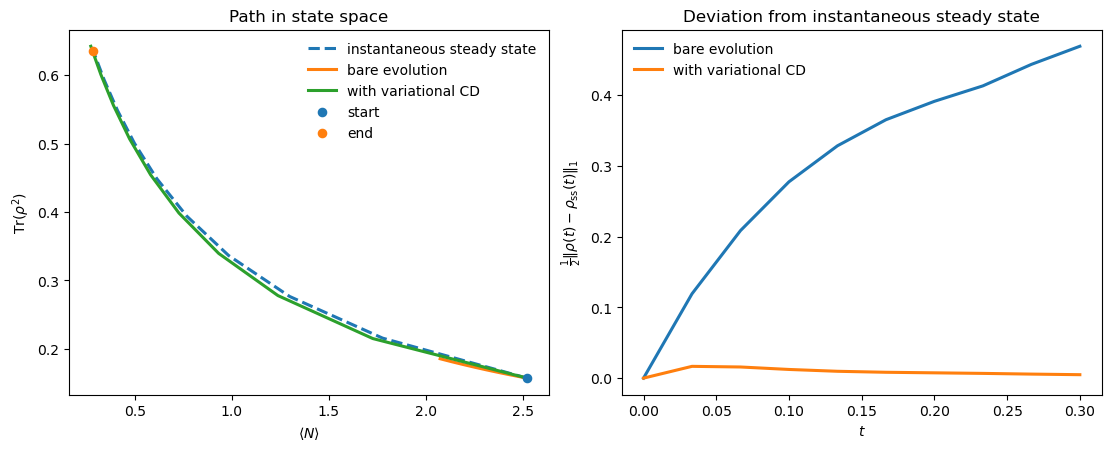

In [117]:
dim = 12
omega = 1.0
bath_gamma = 1.0

a = annihilation_operator(dim)
adag = creation_operator(dim)

results = plot_variational_cd_performance(
    dim=dim,
    omega=omega,
    bath_gamma=bath_gamma,
    beta_i=0.3,
    beta_f=1.5,   # choose beta_f > beta_i so dot(beta) > 0
    T=0.3,
    n_times=10,
    lam=0.0,
    jump_operators=[a],   # NOT a**2
    verbose=True,
)

### 2LS case

In [ ]:
rho_ss=np.array([[1,0],[0,1]])/2
drho_ss=np.array([[1,0],[0,-1]])

jump_operators = [Pauli.sz, Pauli.sx, Pauli.sx+1.j*Pauli.sy]
    
gamma, results = fit_dissipative_agp_nnls(
    rho_ss,
    drho_ss,
    jump_operators,
    lam=0.0,
    return_details=True,
)

print(gamma)
print("Residual norm squared:", results["residual_norm_squared"])
print("Gamma norm squared:", results["gamma_norm_squared"])

[0.  0.  0.5]
Residual norm squared: 0.0
Gamma norm squared: 0.25


### Old hardcoded version

In [ ]:
#----------------------
# Calculate the AGP variationally
#----------------------
def fit_single_dissipator(
    builder,
    rho,
    drho,
    jump_operator,
):
    """
    Solve

        min_c ||drho - c D[L](rho)||_F

    for a real scalar c.
    """
    D = dissipator_from_builder(
        builder,
        jump_operator,
    )

    rho_vec = builder.vec(rho)
    target = builder.vec(drho)

    # Direction in operator space generated by D[L]
    direction = D @ rho_vec

    denominator = np.vdot(
        direction,
        direction,
    ).real

    if denominator < 1e-15:
        raise ValueError(
            "D[L](rho) is numerically zero, so the coefficient "
            "cannot be determined."
        )

    coefficient = (
        np.vdot(direction, target).real
        / denominator
    )

    fitted_target = coefficient * direction
    residual = target - fitted_target

    return {
        "coefficient": coefficient,
        "dissipator": D,
        "superoperator": coefficient * D,
        "fitted_derivative": builder.mat(fitted_target),
        "residual": builder.mat(residual),
        "residual_norm": np.linalg.norm(residual),
        "relative_residual": (
            np.linalg.norm(residual)
            / np.linalg.norm(target)
        ),
    }

result = fit_single_dissipator(
    builder,
    rho_ss,
    drho_ss_dbeta,
    a,
)

print("Optimal coefficient:")
print(result["coefficient"])

print("Residual norm:")
print(result["residual_norm"])

print("Relative residual:")
print(result["relative_residual"])


(1-9.860761315262648e-32j)


/var/folders/h3/s252cnjs1fg5q_2y8x3vh8mr0000gp/T/ipykernel_83807/2655252996.py:4: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(rhoss_num)))


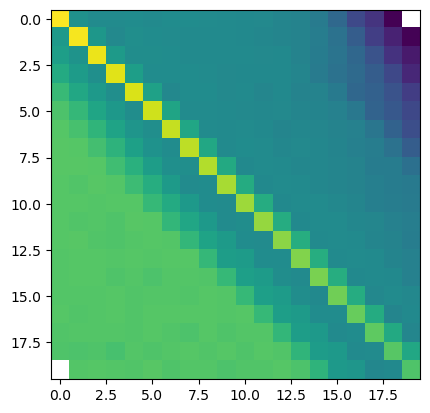

/var/folders/h3/s252cnjs1fg5q_2y8x3vh8mr0000gp/T/ipykernel_83807/2655252996.py:8: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(rhoss)))


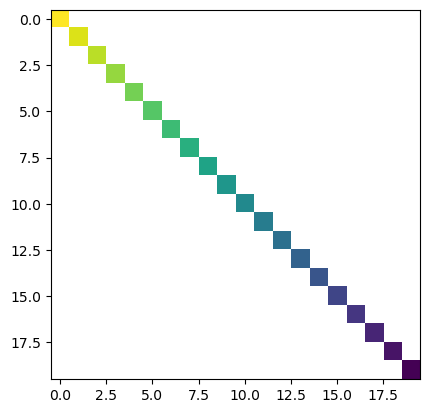

Error in numerics vs. analytics for rho_ss
4.3798335016052187e-14


In [36]:
#Calculate the steady state numerically
rhoss_num=get_steady_state(builder, model, 0.0)
print(np.trace(rhoss_num))
plt.imshow(np.log(np.abs(rhoss_num)))
plt.show()
M=expm(-beta*omega*(adag@a))
rhoss=M/np.trace(M)
plt.imshow(np.log(np.abs(rhoss)))
plt.show()
print("Error in numerics vs. analytics for rho_ss")
print(np.sum(np.abs(rhoss_num-rhoss)))